<a href="https://colab.research.google.com/github/Lozo214/DataScienceProject/blob/main/380_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load in the data

In [ ]:
# Traffice encforcement from 2017 - 2024
Traffic_Enforcement = pd.read_csv('/content/drive/MyDrive/380/Project/Traffic_Enforcement.csv', low_memory=False)

# Traffic Accidents from 2011 - 2024
Traffic_Accidents = pd.read_csv('/content/drive/MyDrive/380/Project/Traffic_Accidents.csv', low_memory=False)

Cleaning Traffic_Enforcement:
1. Drop columns that aren't needed.
2. Move Year and Month Columns to the front.
3. Sort the dataframe by year and month.
4. Create new dataframes for each year.
5. Add the relevant dataframes to a new dataset.
6. Examine the data and check for missing or inconsistent values.


In [ ]:
Traffic_Enforcement = Traffic_Enforcement.drop(columns=['CitationNumber', 'YearToDate', 'Hour', 'Day', 'MonthAbr', 'Division', 'Squad', 'Sex', 'RaceEthnicityGroup', 'Violation', 'MonthFilter', 'ESRI_OID', 'StopDate'])

# Specify the order of columns, moving 'Year' and 'Month' to the front
columns_order = ['Year', 'Month'] + [col for col in Traffic_Enforcement.columns if col not in ['Year', 'Month']]

# Reorder the DataFrame
Traffic_Enforcement = Traffic_Enforcement[columns_order]

# Sort the DataFrame by Year and Month
Traffic_Enforcement = Traffic_Enforcement.sort_values(by=['Year', 'Month'], ascending=[True, True])

# Reset the index after sorting
Traffic_Enforcement.reset_index(drop=True, inplace=True)

# Separate the dataframes by year.
Traffic_Enforcement_2017 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2017]
Traffic_Enforcement_2017 = Traffic_Enforcement_2017.reset_index(drop=True)

Traffic_Enforcement_2018 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2018]
Traffic_Enforcement_2018 = Traffic_Enforcement_2018.reset_index(drop=True)

Traffic_Enforcement_2019 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2019]
Traffic_Enforcement_2019 = Traffic_Enforcement_2019.reset_index(drop=True)

Traffic_Enforcement_2020 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2020]
Traffic_Enforcement_2020 = Traffic_Enforcement_2020.reset_index(drop=True)

Traffic_Enforcement_2021 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2021]
Traffic_Enforcement_2021 = Traffic_Enforcement_2021.reset_index(drop=True)

Traffic_Enforcement_2022 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2022]
Traffic_Enforcement_2022 = Traffic_Enforcement_2022.reset_index(drop=True)

Traffic_Enforcement_2023 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2023]
Traffic_Enforcement_2023 = Traffic_Enforcement_2023.reset_index(drop=True)

# Not enough entries yet. 2024 is out.
# Traffic_Enforcement_2024 = Traffic_Enforcement[Traffic_Enforcement['Year'] == 2024]
# Traffic_Enforcement_2024 = Traffic_Enforcement_2024.reset_index(drop=True)

traffic_enforcement_datasets = {
    "2017": Traffic_Enforcement_2017,
    "2018": Traffic_Enforcement_2018,
    "2019": Traffic_Enforcement_2019,
    "2020": Traffic_Enforcement_2020,
    "2021": Traffic_Enforcement_2021,
    "2022": Traffic_Enforcement_2022,
    "2023": Traffic_Enforcement_2023
}

# This code will print a lengthy description of the dataframes.
'''
for year, dataset in traffic_enforcement_datasets.items():
    print(f"Service Calls {year} Columns:", dataset.columns)
    print(dataset.head())
    print(f"Missing Values in Traffic_Enforcement_{year}:")
    print(dataset.isnull().sum())
    print(f"Description of Traffic_Enforcement_{year}:")
    print(dataset.describe())
    print("-" * 50)
'''
None

Cleaning Traffic_Accidents:
1. Drop columns that aren't needed for our study.
2. Create a new column for the year of the accident and a new column for the month of the accident.
3. Move those columns to the front of the dataframe, as they are the most relevant to our study.
4. Sort the dataframe by year and month.
5. Create new dataframes for each year.
6. Add the relevant dataframes to a new dataset.
7. Examine the data and check for missing or inconsistent values.

In [ ]:
Traffic_Accidents = Traffic_Accidents.drop(Traffic_Accidents.columns[32:], axis=1)
Traffic_Accidents = Traffic_Accidents.drop(columns=[ 'OBJECTID', 'agency', 'acci_id', 'tamainid', 'appstate', 'numunits', 'offense', 'Intersection', 'UnitsVeh',
                                                    'UnitsMCs', 'UnitsPeds', 'UnitsBicycles', 'UnitsOther', 'Date_Occu', 'Hour_Occu', 'DayOfWeek', 'date_rept',
                                                     'hour_rept', 'datetime_rept', 'WeekOfYear', 'WeekDate', 'TransImmedMedCare', 'PRnum', 'emlname'])

# Convert AccidentDateTime to datetime format
Traffic_Accidents['AccidentDateTime'] = pd.to_datetime(Traffic_Accidents['AccidentDateTime'], errors='coerce')

# Extract year and month into new columns
Traffic_Accidents['Year'] = Traffic_Accidents['AccidentDateTime'].dt.year
Traffic_Accidents['Month'] = Traffic_Accidents['AccidentDateTime'].dt.month

# Specify the order of columns, moving 'Year' and 'Month' to the front
columns_order = ['Year', 'Month'] + [col for col in Traffic_Accidents.columns if col not in ['Year', 'Month']]

# Reorder the DataFrame
Traffic_Accidents = Traffic_Accidents[columns_order]

# Sort the DataFrame by Year and Month
Traffic_Accidents = Traffic_Accidents.sort_values(by=['Year', 'Month'], ascending=[True, True])

# Drop the AccidentDateTime column. No longer needed.
Traffic_Accidents = Traffic_Accidents.drop(columns=['AccidentDateTime'])

# Reset the index after sorting
Traffic_Accidents.reset_index(drop=True, inplace=True)

# Separate the dataframes by year.
# 2011 only has two rows, so it's out.
#Traffic_Accidents_2011 = Traffic_Accidents[Traffic_Accidents['Year'] == 2011]

# 2012 doesn't have entries for January through June, so it's out.
#Traffic_Accidents_2012 = Traffic_Accidents[Traffic_Accidents['Year'] == 2012]

Traffic_Accidents_2013 = Traffic_Accidents[Traffic_Accidents['Year'] == 2013]
Traffic_Accidents_2013 = Traffic_Accidents_2013.reset_index(drop=True)

Traffic_Accidents_2014 = Traffic_Accidents[Traffic_Accidents['Year'] == 2014]
Traffic_Accidents_2014 = Traffic_Accidents_2014.reset_index(drop=True)

Traffic_Accidents_2015 = Traffic_Accidents[Traffic_Accidents['Year'] == 2015]
Traffic_Accidents_2015 = Traffic_Accidents_2015.reset_index(drop=True)

Traffic_Accidents_2016 = Traffic_Accidents[Traffic_Accidents['Year'] == 2016]
Traffic_Accidents_2016 = Traffic_Accidents_2016.reset_index(drop=True)

Traffic_Accidents_2017 = Traffic_Accidents[Traffic_Accidents['Year'] == 2017]
Traffic_Accidents_2017 = Traffic_Accidents_2017.reset_index(drop=True)

Traffic_Accidents_2018 = Traffic_Accidents[Traffic_Accidents['Year'] == 2018]
Traffic_Accidents_2018 = Traffic_Accidents_2018.reset_index(drop=True)

Traffic_Accidents_2019 = Traffic_Accidents[Traffic_Accidents['Year'] == 2019]
Traffic_Accidents_2019 = Traffic_Accidents_2019.reset_index(drop=True)

Traffic_Accidents_2020 = Traffic_Accidents[Traffic_Accidents['Year'] == 2020]
Traffic_Accidents_2020 = Traffic_Accidents_2020.reset_index(drop=True)

Traffic_Accidents_2021 = Traffic_Accidents[Traffic_Accidents['Year'] == 2021]
Traffic_Accidents_2021 = Traffic_Accidents_2021.reset_index(drop=True)

# Starting in May, the months don't have enough entries. Likely pandemic related. Leaving 2022 out for now.
# Traffic_Accidents_2022 = Traffic_Accidents[Traffic_Accidents['Year'] == 2022]
# Traffic_Accidents_2022 = Traffic_Accidents_2022.reset_index(drop=True)

# Not enough entries. 2023 is out.
# Traffic_Accidents_2023 = Traffic_Accidents[Traffic_Accidents['Year'] == 2023]
# Traffic_Accidents_2023 = Traffic_Accidents_2023.reset_index(drop=True)

# Not enough entries. 2024 is out.
# Traffic_Accidents_2024 = Traffic_Accidents[Traffic_Accidents['Year'] == 2024]
# Traffic_Accidents_2024 = Traffic_Accidents_2024.reset_index(drop=True)

traffic_accidents_datasets = {
    "2013": Traffic_Accidents_2013,
    "2014": Traffic_Accidents_2014,
    "2015": Traffic_Accidents_2015,
    "2016": Traffic_Accidents_2016,
    "2017": Traffic_Accidents_2017,
    "2018": Traffic_Accidents_2018,
    "2019": Traffic_Accidents_2019,
    "2020": Traffic_Accidents_2020,
    "2021": Traffic_Accidents_2021
}

# This code will print a lengthy description of the dataframes.
'''
for year, dataset in traffic_accidents_datasets.items():
    print(f"Traffic Accidents {year} Columns:", dataset.columns)
    print(dataset.head())
    print(f"Missing Values in Traffic_Accidents_{year}:")
    print(dataset.isnull().sum())
    print(f"Description of Traffic_Accidents_{year}:")
    print(dataset.describe())
    print("-" * 50)
'''
None

Our primary research question is:

Does increased traffic enforcement activity correlate with fewer traffic accidents?

Our hypothesis: There is a negative correlation between the number of traffic citations issued by police and the number of traffic accidents that occur. This means that as the number of police issued citations rise, the number of traffic accidents fall.

To answer this, we're going to look at the number of traffic accidents that occurred in a year and we're going to look at the number of traffic citations that were issued in that same year and see if there is any correlation between this data.

The figure below is a simple line graph showing how many traffic accidents were observed by police each year between 2013 and 2021.

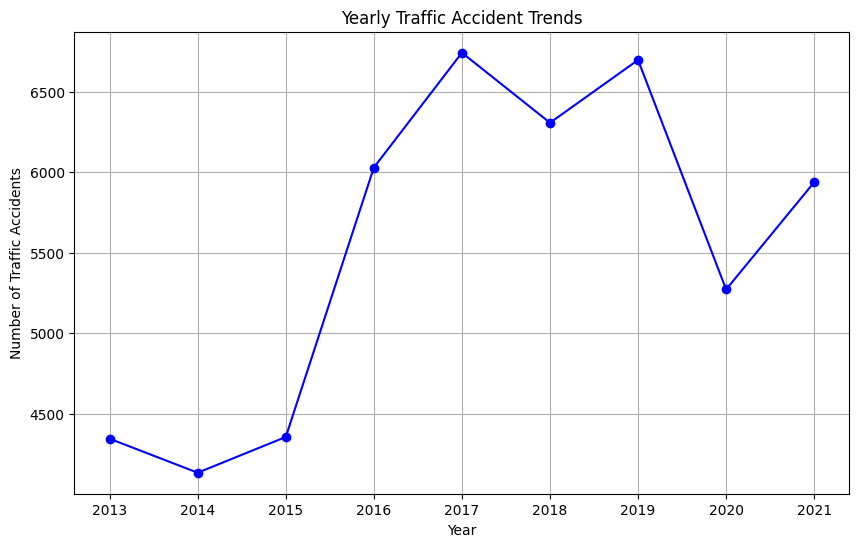

Year
2013    4345
2014    4134
2015    4356
2016    6029
2017    6742
2018    6307
2019    6697
2020    5272
2021    5938
dtype: int64


In [ ]:
# Combine all yearly dataframes into one for aggregation
combined_traffic_accidents = pd.concat(traffic_accidents_datasets.values(), ignore_index=True)

# Aggregate traffic accidents by year
yearly_accidents = combined_traffic_accidents.groupby('Year').size()

# Plot yearly trends
plt.figure(figsize=(10, 6))
plt.plot(yearly_accidents.index, yearly_accidents.values, marker='o', linestyle='-', color='b')
plt.title('Yearly Traffic Accident Trends')
plt.xlabel('Year')
plt.ylabel('Number of Traffic Accidents')
plt.grid(True)
plt.show()

# Display all years with the number of accidents
print(yearly_accidents)

The figure below is a line graph showing how many traffic citations were issued by police each year between 2017 and 2021.

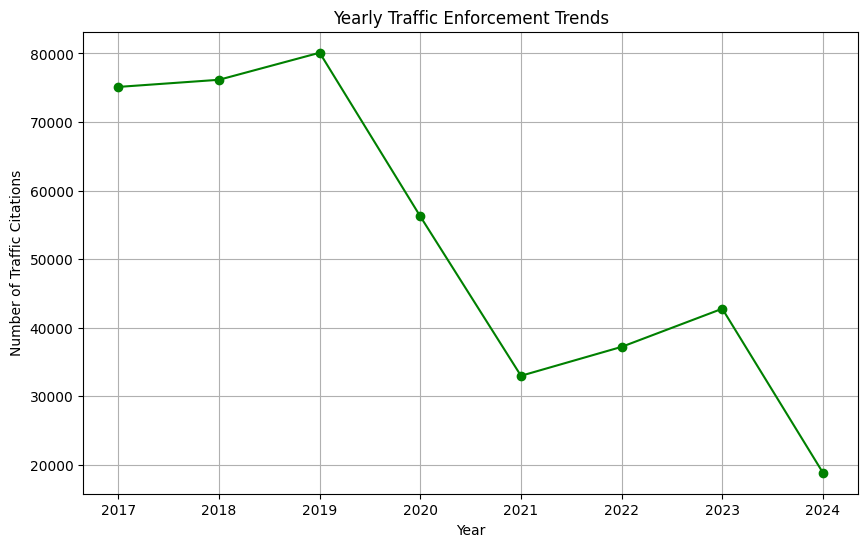

Year
2017    75119
2018    76160
2019    80104
2020    56237
2021    33002
2022    37221
2023    42781
2024    18871
dtype: int64


In [ ]:
# Aggregate traffic enforcement data by year
yearly_enforcement = Traffic_Enforcement.groupby('Year').size()

# Plot yearly trends for traffic enforcement
plt.figure(figsize=(10, 6))
plt.plot(yearly_enforcement.index, yearly_enforcement.values, marker='o', linestyle='-', color='g')
plt.title('Yearly Traffic Enforcement Trends')
plt.xlabel('Year')
plt.ylabel('Number of Traffic Citations')
plt.grid(True)
plt.show()

# Display all years with the number of citations
print(yearly_enforcement)

Now we want to see if there is a correclation between these datasets. Since we have data from both sets that spans the years 2017 - 2021, we will focus our analysis on these years.

In [ ]:
# Filter traffic accidents and enforcement data for years 2017–2021
filtered_years = range(2017, 2022)

# Filter yearly accidents
filtered_accidents = yearly_accidents[yearly_accidents.index.isin(filtered_years)]

# Filter yearly enforcement
filtered_enforcement = yearly_enforcement[yearly_enforcement.index.isin(filtered_years)]

# Combine the filtered data into a single DataFrame
filtered_data = pd.DataFrame({
    'Year': filtered_accidents.index,
    'Traffic_Accidents': filtered_accidents.values,
    'Citations': filtered_enforcement.values
})

# Examine the filtered data
print(filtered_data)

   Year  Traffic_Accidents  Citations
0  2017               6742      75119
1  2018               6307      76160
2  2019               6697      80104
3  2020               5272      56237
4  2021               5938      33002


Next we're going to visualize this data using a scatterplot so we can see if there is an obvious correlation. We are calculating the Pearson correlation coefficient to determine whether the relationship between traffic accidents and traffic enforcement is significant or not.

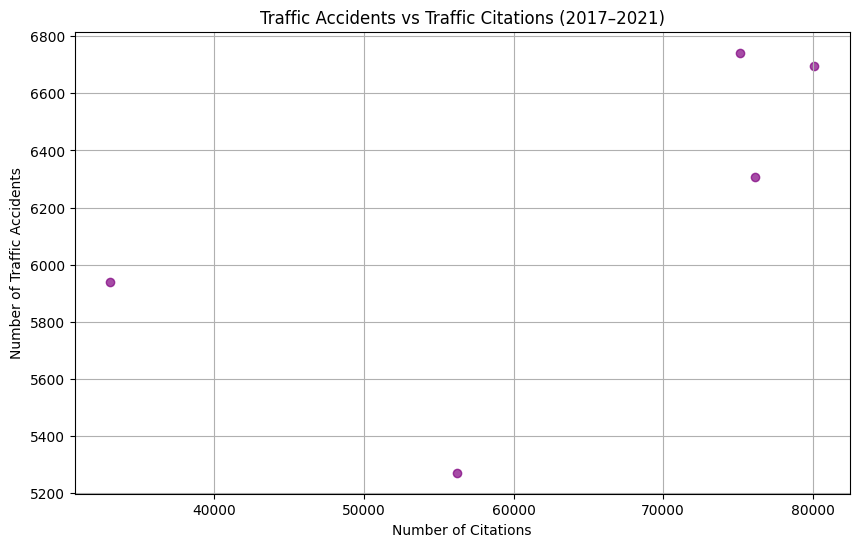

Pearson Correlation Coefficient (2017–2021): 0.64


In [ ]:
# Scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data['Citations'], filtered_data['Traffic_Accidents'], color='purple', alpha=0.7)
plt.title('Traffic Accidents vs Traffic Citations (2017–2021)')
plt.xlabel('Number of Citations')
plt.ylabel('Number of Traffic Accidents')
plt.grid(True)
plt.show()

# Compute the Pearson correlation coefficient
correlation_filtered = filtered_data['Citations'].corr(filtered_data['Traffic_Accidents'])
print(f"Pearson Correlation Coefficient (2017–2021): {correlation_filtered:.2f}")

The Pearson correlation coefficient is 0.6394. This means that traffic enforcement has a positive correlation with the number of accidents, which means that our hypothesis was incorrect.

Although our hypothesis was disproven, we recognize that working with such a limited number of data points could lead to inaccurate results. To achieve more accurate results, we adjusted our study to look at the correlation between traffic accidents and traffic citations on a monthly basis as oppoosed to yearly.

The figures below are visualizations of this monthly data.

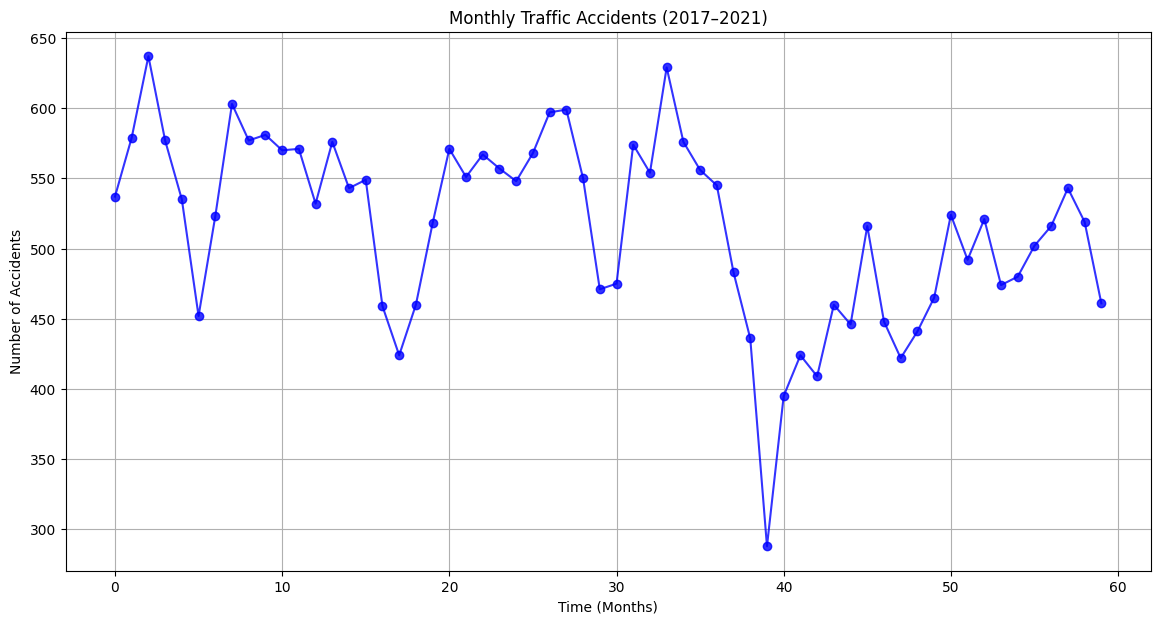

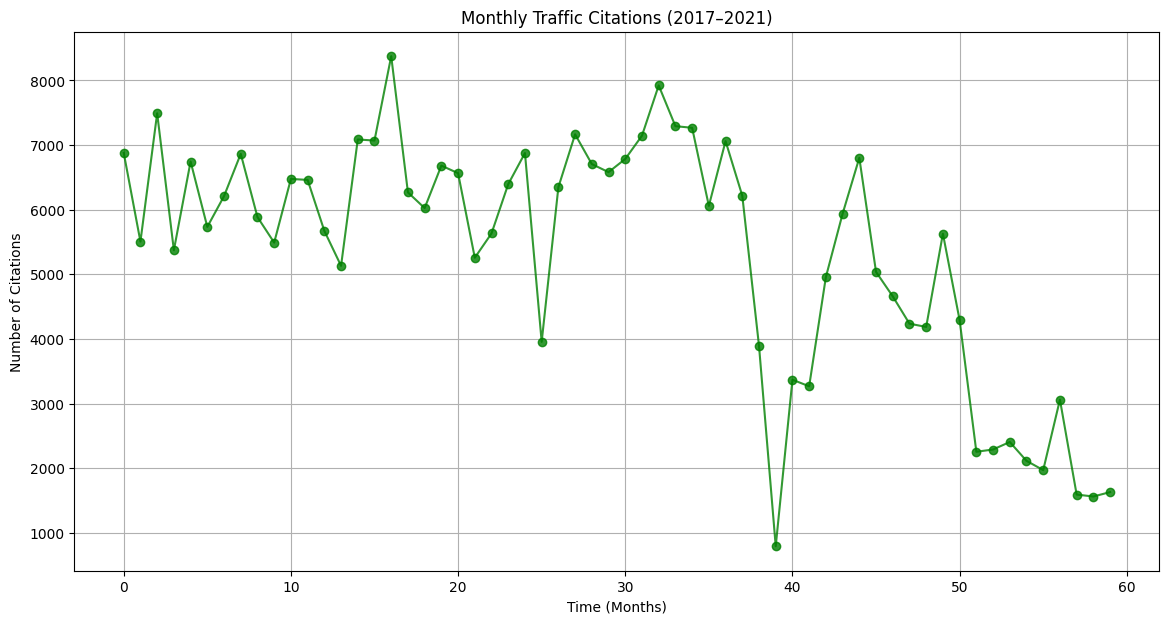

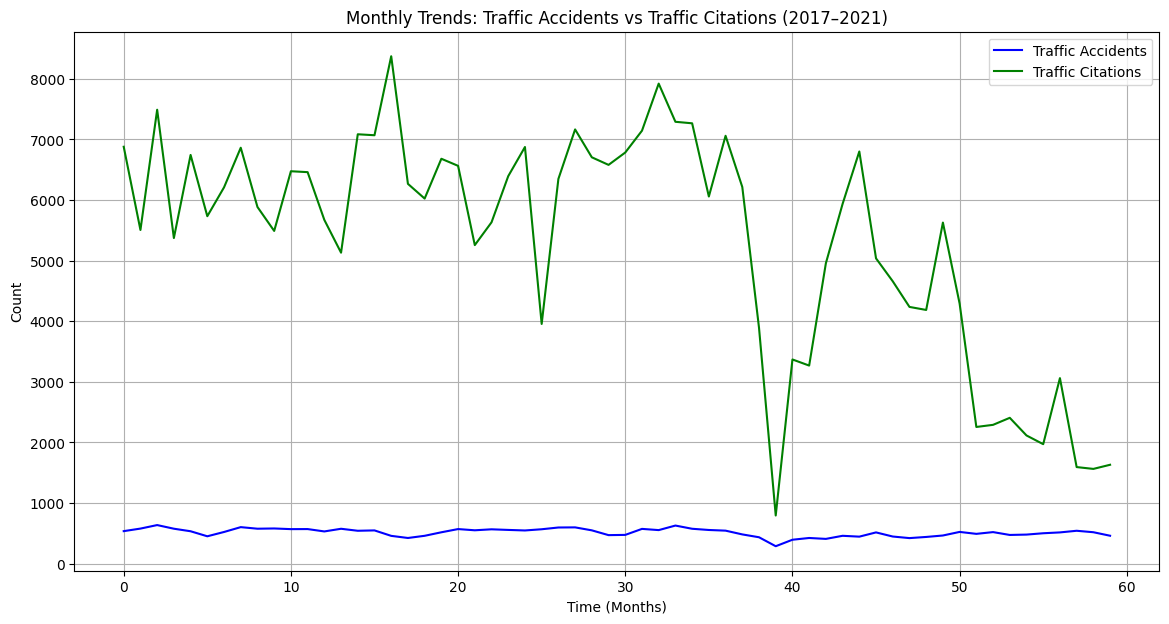

In [ ]:
# Filter the data for the years 2017–2021
filtered_traffic_accidents = combined_traffic_accidents[combined_traffic_accidents['Year'].isin(filtered_years)]
filtered_traffic_enforcement = Traffic_Enforcement[Traffic_Enforcement['Year'].isin(filtered_years)]

# Aggregate data by month (grouping by year and month)
monthly_accidents = filtered_traffic_accidents.groupby(['Year', 'Month']).size().reset_index(name='Accidents')
monthly_citations = filtered_traffic_enforcement.groupby(['Year', 'Month']).size().reset_index(name='Citations')

# Merge the monthly data into a single DataFrame
monthly_data = pd.merge(monthly_accidents, monthly_citations, on=['Year', 'Month'])

# Plot for monthly traffic accidents
plt.figure(figsize=(14, 7))
plt.plot(monthly_data['Accidents'], color='blue', marker='o', linestyle='-', alpha=0.8)
plt.title('Monthly Traffic Accidents (2017–2021)')
plt.xlabel('Time (Months)')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

# Plot for monthly traffic citations
plt.figure(figsize=(14, 7))
plt.plot(monthly_data['Citations'], color='green', marker='o', linestyle='-', alpha=0.8)
plt.title('Monthly Traffic Citations (2017–2021)')
plt.xlabel('Time (Months)')
plt.ylabel('Number of Citations')
plt.grid(True)
plt.show()

# Plot for both
plt.figure(figsize=(14, 7))
plt.plot(monthly_data['Accidents'], label='Traffic Accidents', color='blue')
plt.plot(monthly_data['Citations'], label='Traffic Citations', color='green')
plt.title('Monthly Trends: Traffic Accidents vs Traffic Citations (2017–2021)')
plt.xlabel('Time (Months)')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

To further explore the relationship between these datasets, we can plot them on a scatter plot and calculate their correlation coefficient.

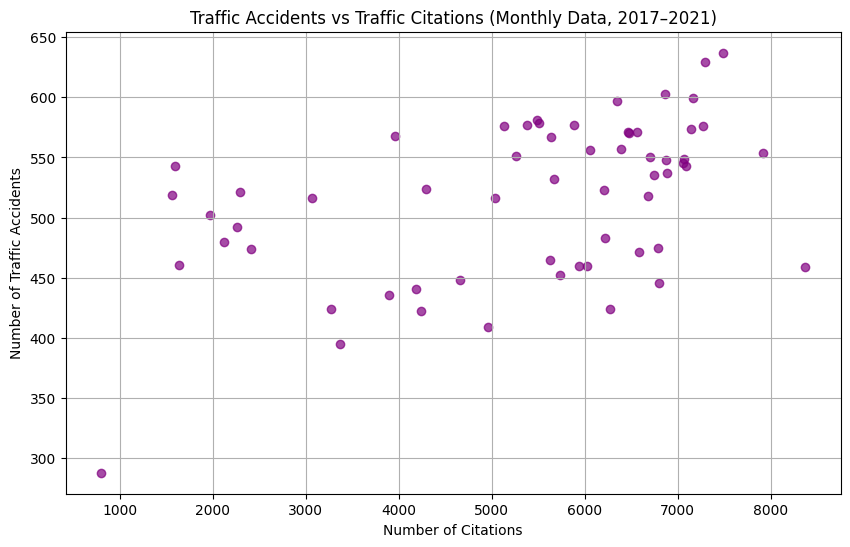

Pearson Correlation Coefficient (Monthly Data): 0.47


In [ ]:
# Plot the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(monthly_data['Citations'], monthly_data['Accidents'], color='purple', alpha=0.7)
plt.title('Traffic Accidents vs Traffic Citations (Monthly Data, 2017–2021)')
plt.xlabel('Number of Citations')
plt.ylabel('Number of Traffic Accidents')
plt.grid(True)
plt.show()

# Calculate the correlation coefficient
monthly_correlation = monthly_data['Citations'].corr(monthly_data['Accidents'])
print(f"Pearson Correlation Coefficient (Monthly Data): {monthly_correlation:.2f}")

The correlation coefficient for the monthly data is 0.4693, which is still a positive correlation. However, it is a bit smaller than the correlation coefficient we calculated for the yearly data, which means that the monthly data shows a weaker correlation than the yearly data did.

Using a linear regression model on this dataset enables us to make predictions about the expected number of traffic accidents in a given month based on the number of traffic citations issued during that month. The train-test split approach was applied to evaluate the model’s performance on both training and unseen test data. On the test set, the Mean Squared Error (MSE) is 2667.17, which indicates the average squared difference between predicted and actual values, suggesting a notable level of error in the predictions. The R-squared value on the test set is 0.066, showing that the model explains only about 6.6% of the variance in traffic accidents for the test data.

On the training set, the MSE is 3487.01, and the R-squared is 0.241, meaning the model performs slightly better on the data it was trained on but still has limited prediction power. These evaluation metrics suggest that while linear regression captures a general trend, it struggles to make accurate predictions and leaves a significant amount of variance unexplained.

The scatter plot and regression line below visualize the test set predictions, showing the linear relationship between citations and accidents and highlighting the limitations of the model's predictive capabilities. This analysis suggests that alternative modeling techniques may yield more accurate and reliable results.

Regression Coefficient: 0.0177
Regression Intercept: 418.8822
Test Set MSE: 2667.1701
Test Set R-squared: 0.0658
Train Set MSE: 3487.0143
Train Set R-squared: 0.2410


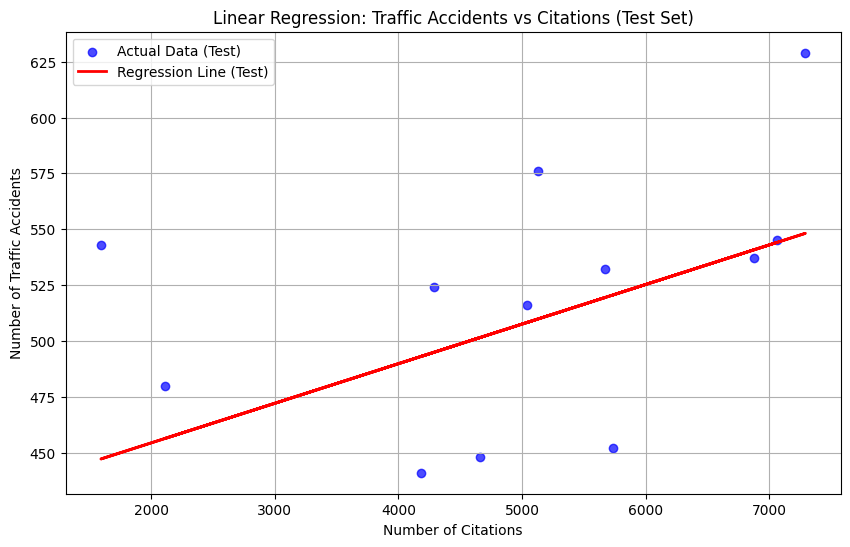

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Prepare the data
X_monthly = monthly_data['Citations'].values.reshape(-1, 1)
y_monthly = monthly_data['Accidents'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_monthly, y_monthly, test_size=0.2, random_state=42)

# Initialize and train
reg_model_monthly = LinearRegression()
reg_model_monthly.fit(X_train, y_train)

# Print the regression coefficient and intercept
print(f"Regression Coefficient: {reg_model_monthly.coef_[0]:.4f}")
print(f"Regression Intercept: {reg_model_monthly.intercept_:.4f}")

# Predict values for the test set
y_pred_test = reg_model_monthly.predict(X_test)

# Predict values for the training set
y_pred_train = reg_model_monthly.predict(X_train)

# Evaluate the model on the test set
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Evaluate the model on the training set
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Print evaluation metrics
print(f"Test Set MSE: {mse_test:.4f}")
print(f"Test Set R-squared: {r2_test:.4f}")
print(f"Train Set MSE: {mse_train:.4f}")
print(f"Train Set R-squared: {r2_train:.4f}")

# Plot test set predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Data (Test)')
plt.plot(X_test, y_pred_test, color='red', linewidth=2, label='Regression Line (Test)')
plt.title('Linear Regression: Traffic Accidents vs Citations (Test Set)')
plt.xlabel('Number of Citations')
plt.ylabel('Number of Traffic Accidents')
plt.legend()
plt.grid(True)
plt.show()


After observing the limitations of the linear regression model, we explored a decision tree regression model to better capture the underlying patterns in the data. Decision trees are known for their ability to model non-linear relationships and segment data into meaningful intervals, potentially improving predictive performance.

Using a train-test split, the model was evaluated on both training and test datasets. On the training set, the MSE is 1771.99, and the R-squared score is 0.61, indicating that the decision tree can explain 61% of the variance in traffic accidents for the training data. On the test set, the MSE is 2353.93, and the R-squared score is 0.18, showing moderate predictive performance on unseen data.

Compared to the linear regression model, the decision tree demonstrates a substantial improvement in performance on the training data, with a lower MSE and higher R-squared. However, its performance on the test data suggests potential overfitting or limitations due to the simplicity of the features. The scatter plot below shows the decision tree's predictions compared to the actual test data, highlighting its ability to capture stepwise patterns in the data.

Decision Tree Training MSE: 1771.99
Decision Tree Training R-squared: 0.61
Decision Tree Testing MSE: 2353.93
Decision Tree Testing R-squared: 0.18


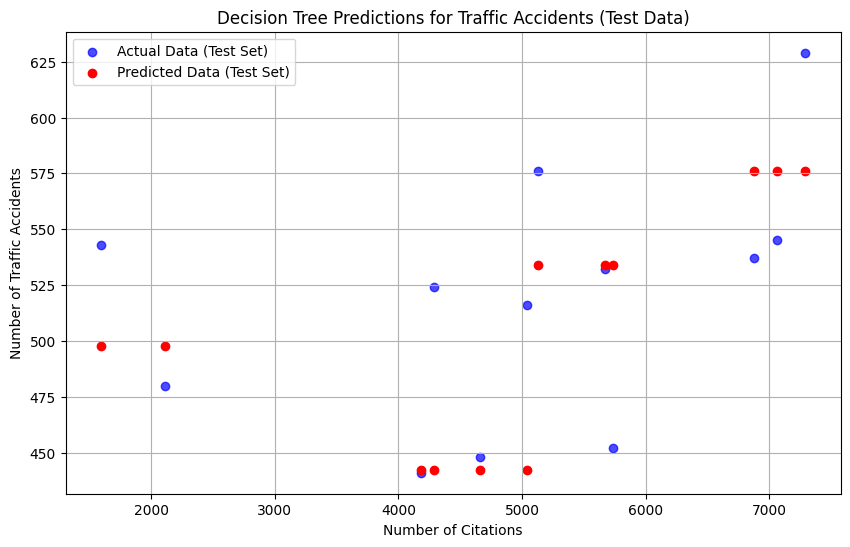

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Prepare the data
X_monthly = monthly_data['Citations'].values.reshape(-1, 1)
y_monthly = monthly_data['Accidents'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_monthly, y_monthly, test_size=0.2, random_state=42)

# Fit a Decision Tree model on the training data
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Predict traffic accidents
y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

# Evaluate the model on training data
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"Decision Tree Training MSE: {mse_train:.2f}")
print(f"Decision Tree Training R-squared: {r2_train:.2f}")

# Evaluate the model on testing data
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
print(f"Decision Tree Testing MSE: {mse_test:.2f}")
print(f"Decision Tree Testing R-squared: {r2_test:.2f}")

# Plot Decision Tree predictions on test data
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Actual Data (Test Set)')
plt.scatter(X_test, y_pred_test, color='red', label='Predicted Data (Test Set)')
plt.title('Decision Tree Predictions for Traffic Accidents (Test Data)')
plt.xlabel('Number of Citations')
plt.ylabel('Number of Traffic Accidents')
plt.legend()
plt.grid(True)
plt.show()

In conclusion, it appears that the number of traffic citations written is a poor predictor of the number of accidents that occur.